# Лабораторная работа 2. Линейная регрессия

Загрузите датасет auto-mpg.csv из папки datasets

В качестве x возьмите horsepower

В качестве y - mpg

In [1]:
import pandas as pd
from scipy.stats import iqr

df = pd.read_csv('auto-mpg.csv')

print("\ndataset info:")
df.info()


dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396 entries, 0 to 395
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    396 non-null    int64  
 1   mpg           396 non-null    float64
 2   cylinders     396 non-null    int64  
 3   displacement  396 non-null    float64
 4   horsepower    396 non-null    float64
 5   weight        396 non-null    int64  
 6   acceleration  396 non-null    float64
 7   model-year    396 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 24.9 KB


In [2]:
# visualize plot util
def plot_results(y_true, y_pred, model_name=""):
    residuals = y_true - y_pred
    plt.figure(figsize=(12, 5))

    # Plot 1: Real vs predicted
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, color='blue', alpha=0.5, label='Data')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--', linewidth=2, label='Perfect prediction')
    plt.title(f'Real vs predicted values\n({model_name})')
    plt.xlabel('Real y')
    plt.ylabel('Predicted y (y_pred)')
    plt.legend()
    plt.grid(True)

    # Plot 2: Residuals
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, color='purple', alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.title(f'Residual Plot\n({model_name})')
    plt.xlabel('Predicted values (y_pred)')
    plt.ylabel('Residuals (y - y_pred)')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

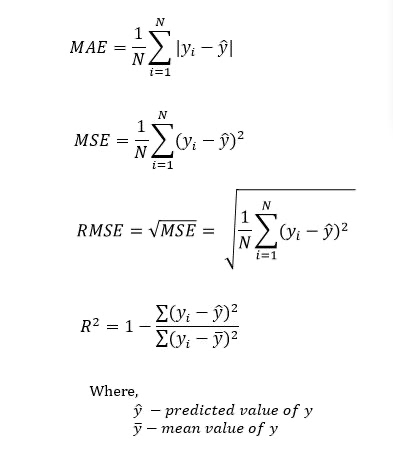 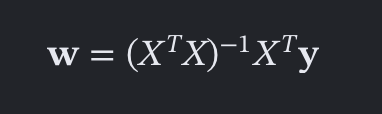 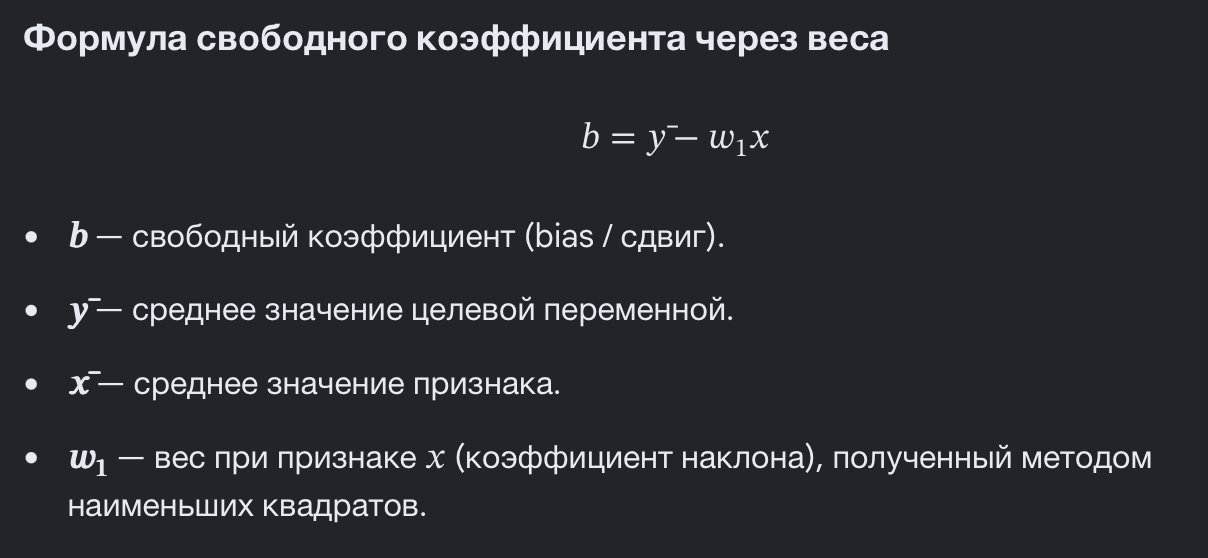

# Задание 1

Обучите модели линейной регрессии. Посчитайте метрики MSE, MAE, R^2. Нарисуйте графики предсказанные значения/остатки. Виды моделей:

1. $y = wx$
2. $y = wx+b$
3. $y = wx^2$
4. $y = w/x$
5. $y = wlog(x)$

Какая из этих моделей подходит лучше?


=== Metrics ===
Mean Squared Error (MSE) : 215.5740
Mean Absolute Error (MAE): 12.2594
Coefficient of Determination (R²): -2.5212


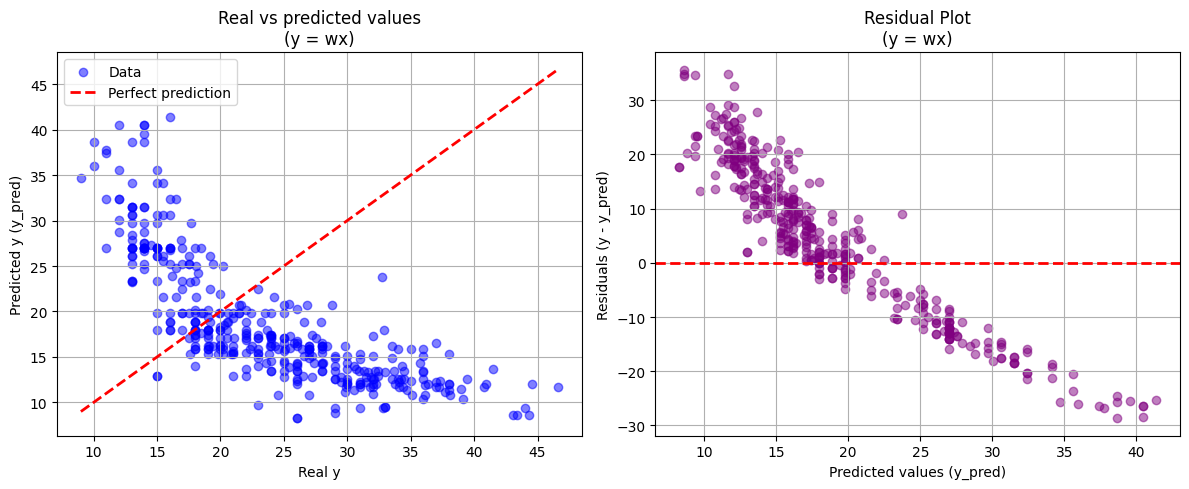

In [3]:
#1
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# MSE, MAE, R^2
import matplotlib.pyplot as plt
import numpy as np

X = df[['horsepower']]
y = df['mpg']

# fit_intercept=False <=> no b, y = wx
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y - y_pred

#plots
plot_results(y, y_pred, "y = wx")


=== Metrics ===
Mean Squared Error (MSE) : 24.2060
Mean Absolute Error (MAE): 3.8523
Coefficient of Determination (R²): 0.6046


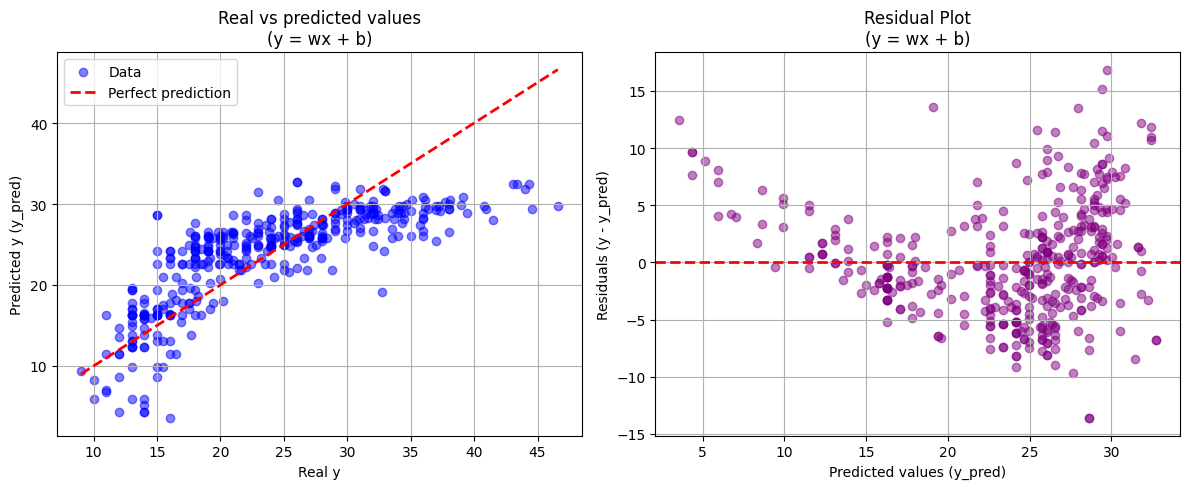

In [4]:
#2
model = LinearRegression(fit_intercept=True)
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y - y_pred

#plots
plot_results(y, y_pred, "y = wx + b")


=== Metrics ===
Mean Squared Error (MSE) : 390.1955
Mean Absolute Error (MAE): 17.2385
Coefficient of Determination (R²): -5.3734


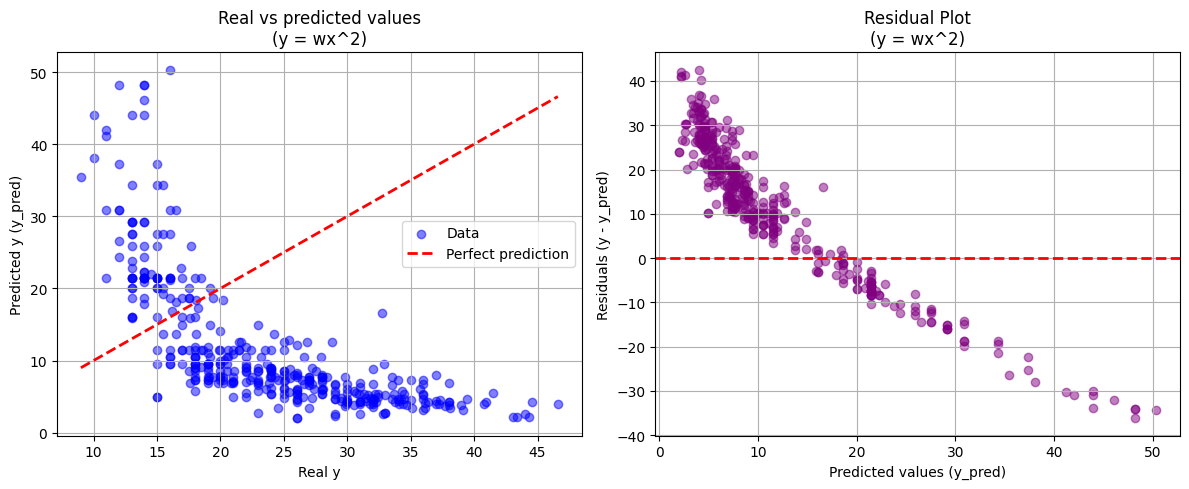

In [5]:
#3
df['horsepower_sq'] = df['horsepower'] ** 2

X = df[['horsepower_sq']] 
y = df['mpg']

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y - y_pred

#plots
plot_results(y, y_pred, "y = wx^2")


=== Metrics ===
Mean Squared Error (MSE) : 21.8246
Mean Absolute Error (MAE): 3.3697
Coefficient of Determination (R²): 0.6435


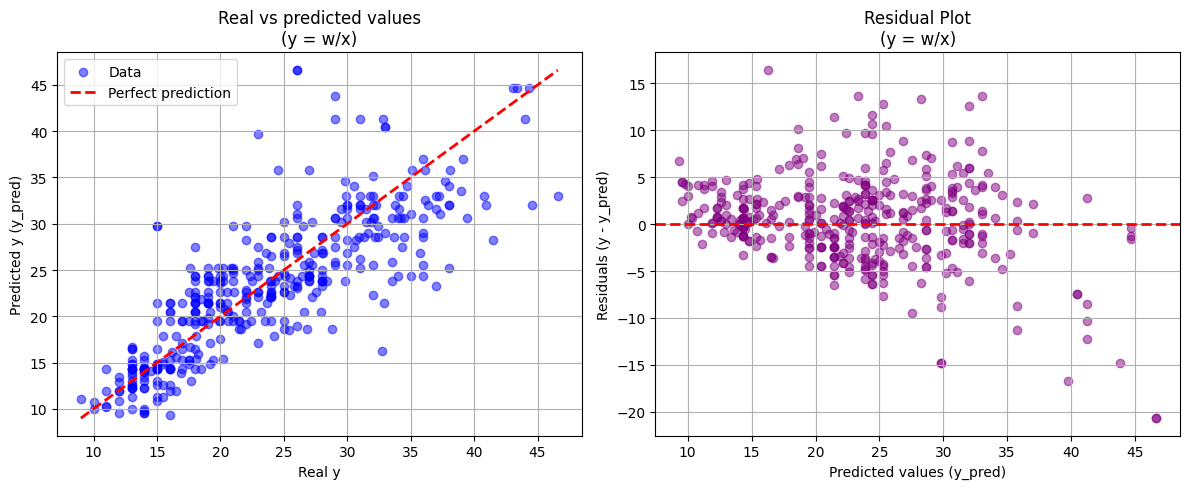

In [6]:
#4
df['horsepower_inverse'] = 1 / df['horsepower']
X = df[['horsepower_inverse']] 
y = df['mpg']

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y - y_pred

#plots
plot_results(y, y_pred, "y = w/x")


=== Metrics ===
Mean Squared Error (MSE) : 86.3739
Mean Absolute Error (MAE): 7.7500
Coefficient of Determination (R²): -0.4108


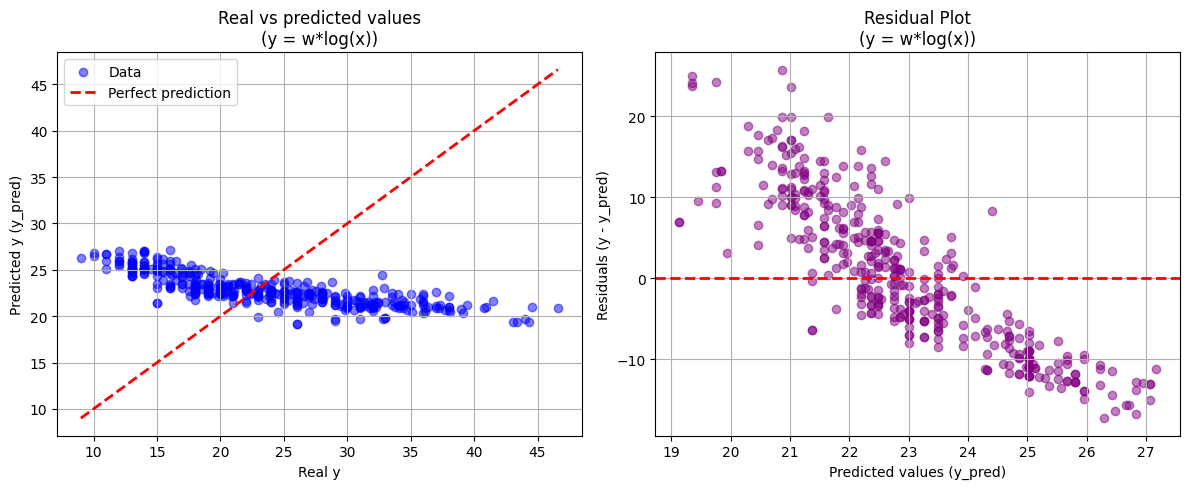

In [7]:
#5
df['horsepower_log'] = np.log(df['horsepower'])
X = df[['horsepower_log']] 
y = df['mpg']

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y - y_pred

#plots
plot_results(y, y_pred, "y = w*log(x)")


=== Metrics ===
Mean Squared Error (MSE) : 200.2373
Mean Absolute Error (MAE): 11.7214
Coefficient of Determination (R²): -3.0878


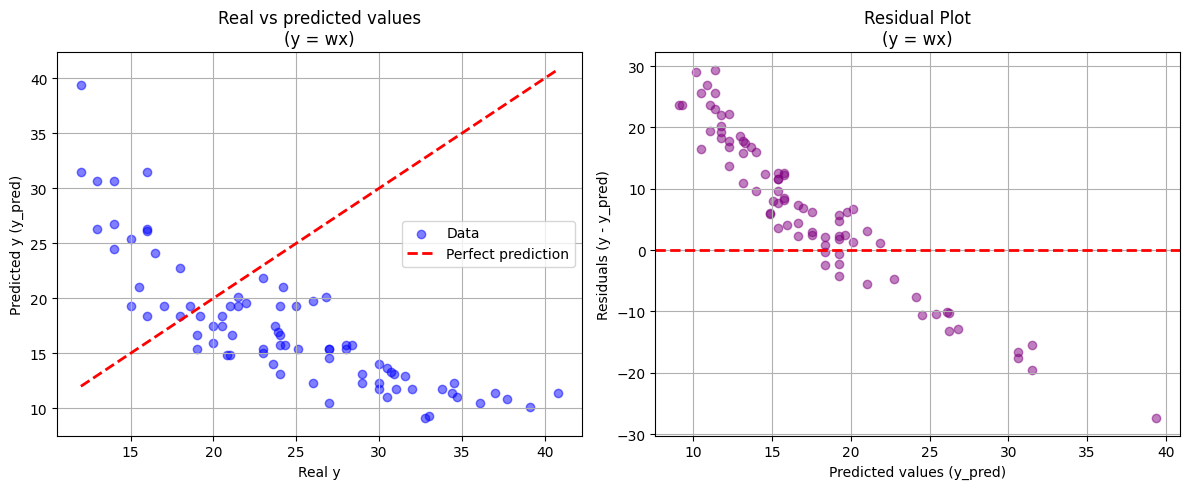

In [8]:
# lab2 with train/test split - 1
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=666
)

X_train = train_df[['horsepower']]
y_train = train_df['mpg']

X_test = test_df[['horsepower']]
y_test = test_df['mpg']

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y_test - y_pred

#plots
plot_results(y_test, y_pred, "y = wx")


=== Metrics ===
Mean Squared Error (MSE) : 15.5855
Mean Absolute Error (MAE): 3.1996
Coefficient of Determination (R²): 0.6818


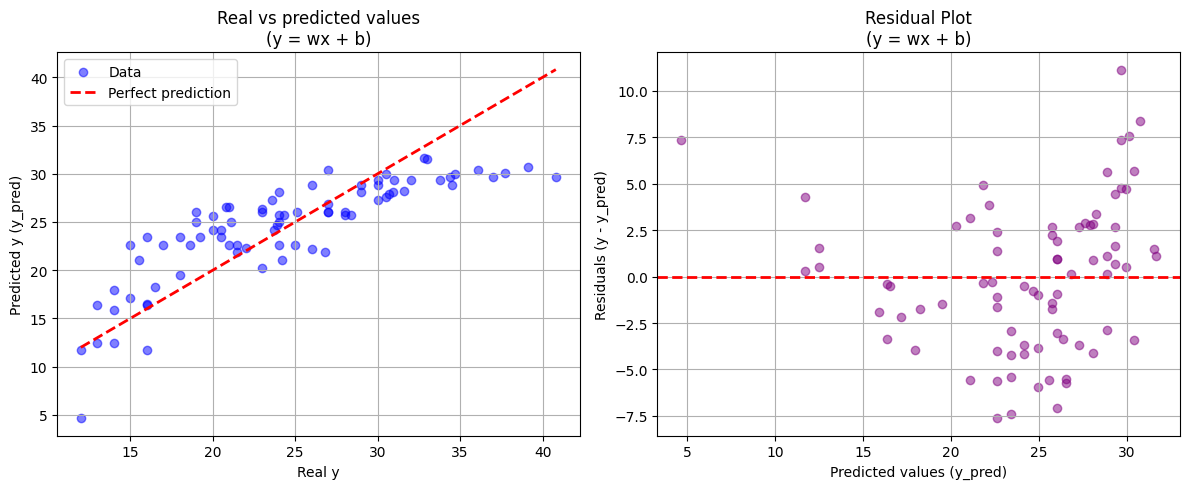

In [9]:
# lab2 with train/test split - 2

model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y_test - y_pred

#plots
plot_results(y_test, y_pred, "y = wx + b")


=== Metrics ===
Mean Squared Error (MSE) : 389.1508
Mean Absolute Error (MAE): 17.4561
Coefficient of Determination (R²): -6.9445


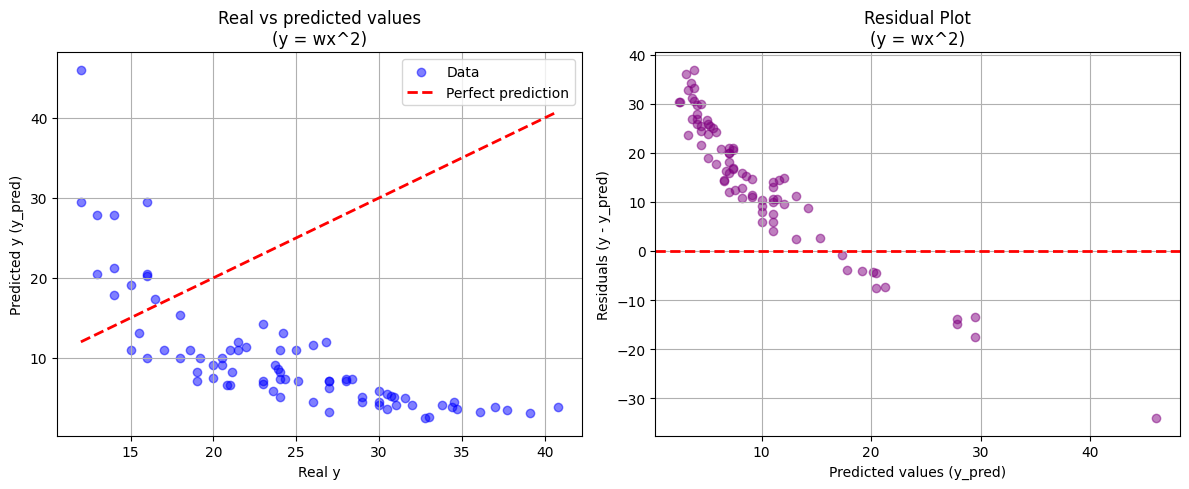

In [10]:
# lab2 with train/test split - 3

X_train = train_df[['horsepower_sq']]

X_test = test_df[['horsepower_sq']]

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y_test - y_pred

#plots
plot_results(y_test, y_pred, "y = wx^2")


=== Metrics ===
Mean Squared Error (MSE) : 12.1052
Mean Absolute Error (MAE): 2.7723
Coefficient of Determination (R²): 0.7529


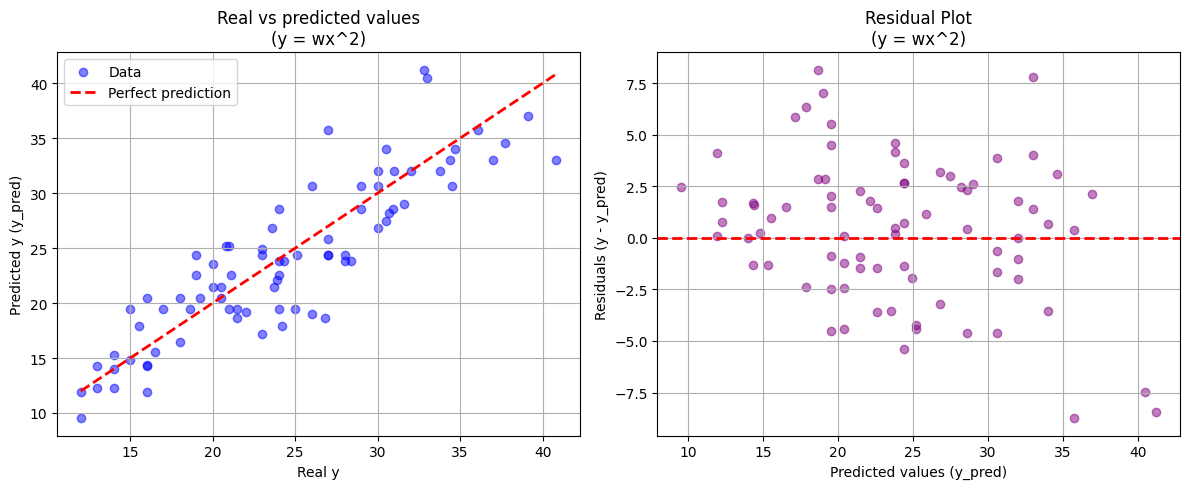

In [11]:
# lab2 with train/test split - 4

X_train = train_df[['horsepower_inverse']]

X_test = test_df[['horsepower_inverse']]

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y_test - y_pred

#plots
plot_results(y_test, y_pred, "y = wx^2")


=== Metrics ===
Mean Squared Error (MSE) : 73.6607
Mean Absolute Error (MAE): 6.9953
Coefficient of Determination (R²): -0.5038


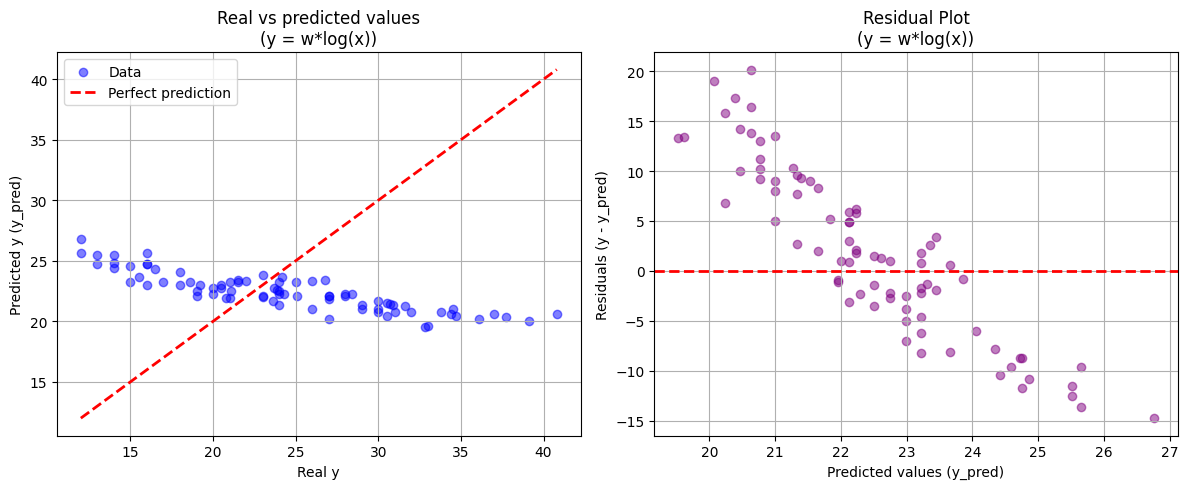

In [12]:
# lab2 with train/test split - 5

X_train = train_df[['horsepower_log']]

X_test = test_df[['horsepower_log']]

model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n=== Metrics ===")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R²): {r2:.4f}")

residuals = y_test - y_pred

#plots
plot_results(y_test, y_pred, "y = w*log(x)")